In [3]:
import h5py
import pandas as pd
from PIL import Image
import numpy as np
import os
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.rich import tqdm

In [10]:
def create_h5_file(json_data, image_path, output_path):
    # Carica l'immagine e convertila in un array numpy
    image = Image.open(image_path)
    image_array = np.array(image)
    
    # Crea un file HDF5
    with h5py.File(output_path, 'w') as h5f:
        # Crea un dataset per l'immagine
        h5f.create_dataset('STM_image', data=image_array, compression="gzip", compression_opts=9)
        
        # Crea un gruppo per i dati JSON
        json_group = h5f.create_group('properties')
        
        # Aggiungi i dati JSON al gruppo
        for key, value in json_data.items():
            if isinstance(value, (int, float, str, bytes)):
                json_group.attrs[key] = value
            elif isinstance(value, list):
                json_group.create_dataset(key, data=np.array(value))
            else:
                raise ValueError(f"Unsupported data type for key {key}: {type(value)}")

# Esempio di utilizzo
csv_file = './dataset.csv'
image_folder = '/home/mario/jobs/git_folders/AutoDFTB/test_batch/transport/stm_images'
output_folder = './h5_files'

# Leggi il file CSV
df = pd.read_csv(csv_file)

# Assumendo che la prima colonna contenga i nomi dei file
for index, row in df.iterrows():
    file_name = row[0]
    json_data = row[1:].to_dict()
    print(json_data)
    image_path = os.path.join(image_folder, file_name + '_e.png')  # Modifica l'estensione dell'immagine se necessario
    output_path = os.path.join(output_folder, file_name + '.h5')
    
    create_h5_file(json_data, image_path, output_path)
    print(f'Creato file H5 per {file_name}')
    


{'num_atoms': 314, 'total_energy': -18473.7266, 'num_electrons': 756.0, 'Fermi_energy': -5.1797, 'electron_affinity': 5.117399999999179, 'ionization_potential': -5.27560000000085, 'band_gap': -10.393000000000027, 'total_energy+1': -18468.451, 'total_energy-1': -18478.844, 'current': 1.55976e-06, 'batch': 2}
Creato file H5 per graphene_67
{'num_atoms': 327, 'total_energy': -19117.496, 'num_electrons': 782.0, 'Fermi_energy': -5.2578, 'electron_affinity': 5.208099999999831, 'ionization_potential': -5.36109999999826, 'band_gap': -10.56919999999809, 'total_energy+1': -19112.1349, 'total_energy-1': -19122.7041, 'current': 7.30375e-07, 'batch': 2}
Creato file H5 per graphene_404
{'num_atoms': 330, 'total_energy': -19285.7121, 'num_electrons': 788.0, 'Fermi_energy': -5.2354, 'electron_affinity': 5.186699999998382, 'ionization_potential': -5.333600000001752, 'band_gap': -10.520300000000134, 'total_energy+1': -19280.3785, 'total_energy-1': -19290.8988, 'current': 1.26317e-06, 'batch': 2}
Creato 

/tmp/ipykernel_3333899/1822871526.py:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  file_name = row[0]


In [7]:
def print_h5_contents(file_path):
    with h5py.File(file_path, 'r') as h5f:
        def print_attrs(name, obj):
            if isinstance(obj, h5py.Dataset):
                print(f'Dataset: {name}')
                print(f'    Shape: {obj.shape}')
                print(f'    Dtype: {obj.dtype}')
                print(f'    Data: {np.array(obj)}\n')
            elif isinstance(obj, h5py.Group):
                print(f'Group: {name}')
                for key, val in obj.attrs.items():
                    print(f'    Attribute: {key} = {val}')
            if isinstance(obj, h5py.AttributeManager):
                for key, val in obj.attrs.items():
                    print(f'    Attribute: {key} = {val}')
        
        h5f.visititems(print_attrs)

# Esempio di utilizzo
file_path = '/home/mario/jobs/git_folders/AutoDFTB/paper/h5_files/graphene_67.h5'
print_h5_contents(file_path)

Dataset: STM_image
    Shape: (256, 256, 3)
    Dtype: uint8
    Data: [[[27  0  0]
  [25  0  0]
  [22  0  0]
  ...
  [10  0  0]
  [ 8  0  0]
  [ 8  0  0]]

 [[30  0  0]
  [30  0  0]
  [25  0  0]
  ...
  [12  0  0]
  [10  0  0]
  [ 8  0  0]]

 [[32  0  0]
  [30  0  0]
  [27  0  0]
  ...
  [12  0  0]
  [12  0  0]
  [10  0  0]]

 ...

 [[40  0  0]
  [40  0  0]
  [38  0  0]
  ...
  [20  0  0]
  [20  0  0]
  [18  0  0]]

 [[45  0  0]
  [42  0  0]
  [40  0  0]
  ...
  [18  0  0]
  [15  0  0]
  [15  0  0]]

 [[45  0  0]
  [45  0  0]
  [40  0  0]
  ...
  [15  0  0]
  [12  0  0]
  [12  0  0]]]

Group: properties
    Attribute: Fermi_energy = -5.1797
    Attribute: band_gap = -10.393000000000027
    Attribute: batch = 2
    Attribute: current = 1.55976e-06
    Attribute: electron_affinity = 5.117399999999179
    Attribute: ionization_potential = -5.27560000000085
    Attribute: num_atoms = 314
    Attribute: num_electrons = 756.0
    Attribute: total_energy = -18473.7266
    Attribute: total_en

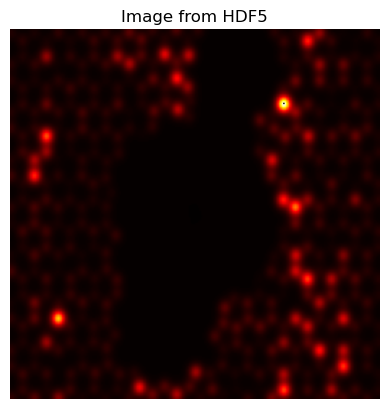

In [9]:
def extract_and_plot_image(file_path, image_dataset_path):
    with h5py.File(file_path, 'r') as h5f:
        if image_dataset_path in h5f:
            image_data = np.array(h5f[image_dataset_path])
            
            # Plotta l'immagine utilizzando matplotlib
            plt.imshow(image_data, cmap='gray')
            plt.title('Image from HDF5')
            plt.axis('off')  # Rimuove gli assi per una visualizzazione migliore
            plt.show()
        else:
            print(f"Dataset {image_dataset_path} not found in file {file_path}")

# Esempio di utilizzo
file_path = '/home/mario/jobs/git_folders/AutoDFTB/paper/h5_files/graphene_67.h5'
image_dataset_path = 'STM_image'  # Questo dovrebbe essere il percorso al dataset dell'immagine nel file HDF5
extract_and_plot_image(file_path, image_dataset_path)

In [6]:
def read_from_xyz_file(file_path: Path):
    """Read xyz files and return lists of x,y,z coordinates and atoms"""
    
    symbol_to_atomic_number = {
        "H": 1, "He": 2, "Li": 3, "Be": 4, "B": 5,
        "C": 6, "N": 7, "O": 8, "F": 9, "Ne": 10,
        "Na": 11, "Mg": 12, "Al": 13, "Si": 14, "P": 15,
        "S": 16, "Cl": 17, "Ar": 18, "K": 19, "Ca": 20,
        # Aggiungi altri elementi se necessario
    }

    X = []
    Y = []
    Z = []
    atoms = []

    with open(str(file_path), "r") as f:
        num_atom = int(next(f))
        next(f)  # ignore the comment

        for _ in range(num_atom):
            l = next(f).split()
            if len(l) == 4 or len(l) == 5:
                X.append(float(l[1]))
                Y.append(float(l[2]))
                Z.append(float(l[3]))
                
                atomic_number = symbol_to_atomic_number.get(str(l[0]))
                if atomic_number is None:
                    raise ValueError(f"Simbolo chimico sconosciuto: {str(l[0])}")
                atoms.append(atomic_number)

    X = np.asarray(X)
    Y = np.asarray(Y)
    Z = np.asarray(Z)
    
    coords = np.stack((X,Y,Z),axis=1)

    return atoms, coords

In [7]:
#file_name,num_atoms,total_energy,num_electrons,Fermi_energy,electron_affinity,ionization_potential,band_gap,total_energy+1,total_energy-1,current
package_path = Path("/home/tommaso/git_workspace/AutoDFTB")
output_path = Path("./h5_files")
csv_file = Path("./dataset.csv")
samples_for_file = 10000

# Leggi il file CSV
df = pd.read_csv(csv_file)

# Calcola il numero totale di slice necessari
num_slices = len(df) // samples_for_file + (len(df) % samples_for_file != 0)

# Divide il DataFrame in slice
slices = [df[i*samples_for_file:(i+1)*samples_for_file] for i in range(num_slices)]

# Crea un file HDF5
for i, slice_df in enumerate(slices):
    with h5py.File(output_path.joinpath(f"dataset_{i}.h5"), 'w') as h5f:
        # Attributi generali
        h5f.attrs['title'] = 'Dataset Esempio FAIR'
        h5f.attrs['description'] = 'Un esempio di come creare un dataset HDF5 seguendo i principi FAIR.'
        h5f.attrs['author'] = 'Nome Ricercatore'
        h5f.attrs['created'] = '2024-07-23'
        h5f.attrs['license'] = 'CC-BY-4.0'
        h5f.attrs['doi'] = '10.1234/example.doi'
        h5f.attrs['url'] = 'https://zenodo.org/record/1234567'
        h5f.attrs['version'] = '1.0'
        h5f.attrs['last_updated'] = '2024-07-23'
        
        # Documentazione
        docs_group = h5f.create_group('documentation')
        docs_group.attrs['description'] = 'Documentazione completa sul dataset e sulle metodologie utilizzate.'
        docs_group.create_dataset('full_description', data=np.string_(
            "Questo dataset contiene misurazioni di temperatura e pressione raccolte nel corso di un esperimento..."
        ))

        
        pbar = tqdm(total=len(slice_df))
        for index, row in slice_df.iterrows():
            file_name = row[0]
            json_data = row[1:].to_dict()
            image_path = package_path.joinpath(f"data_batch_{json_data['batch']}","transport","stm_images",f"{file_name}_e.png")
            
            # Carica l'immagine e convertila in un array numpy
            image = Image.open(image_path)
            image_array = np.array(image)
            
            master_group = h5f.create_group(f'{file_name}')
            master_group.attrs['description'] = f"Simulated data regarding the flake: {file_name}"
            
            #STM image
            stm_data = master_group.create_dataset('STM_image', data=image_array, compression="gzip", compression_opts=9)
            stm_data.attrs['description'] = "STM image of the flake"
            
            #Optimized geometry
            atoms,coords = read_from_xyz_file(package_path.joinpath(f"data_batch_{json_data['batch']}","dftb","xyz_files_fixed_opt",f"{file_name}_opt.xyz"))
            optimized_geom = master_group.create_group("OptGeom")
            
            atoms_data = optimized_geom.create_dataset("AtomicNumbers",data=atoms)
            atoms_data.attrs['description']=""
            
            coords_data = optimized_geom.create_dataset("Coordinates",data=coords)
            coords_data.attrs['units'] = 'Armstrong'
            coords_data.attrs['description']=""
            
            #Num atoms
            n_atoms_data = master_group.create_dataset("NumAtoms", data=json_data['num_atoms'])
            n_atoms_data.attrs['description'] = "Number of atoms of the flake"
            
            #Num electrons
            n_electrons_data = master_group.create_dataset("NumElectrons", data=json_data['num_electrons'])
            n_electrons_data.attrs['description'] = "Number of electrons of the flake"
            
            #Total energy
            total_energy_data = master_group.create_dataset("TotalEnergy", data=json_data["total_energy"])
            total_energy_data.attrs['units'] = "eV"
            total_energy_data.attrs['description'] = "Total energy of the flake"
            
            #Fermi_energy
            fermi_energy_data = master_group.create_dataset("FermiEnergy", data=json_data["Fermi_energy"])
            fermi_energy_data.attrs['units'] = "eV"
            fermi_energy_data.attrs['description'] = "Fermi energy of the flake"
            
            #EA
            EA_data = master_group.create_dataset("EA", data=json_data["electron_affinity"])
            EA_data.attrs['units'] = "eV"
            EA_data.attrs['description'] = "Electron affinity of the flake"
            
            #IP
            IP_data = master_group.create_dataset("IP", data=json_data["ionization_potential"])
            IP_data.attrs['units'] = "eV"
            IP_data.attrs['description'] = "Ionization potential of the flake"
            
            #Band gap
            band_gap_data = master_group.create_dataset("BandGap", data=json_data["band_gap"])
            band_gap_data.attrs['units'] = "eV"
            band_gap_data.attrs['description'] = "Band gap of the flake"
            
            #Optimized electrodes
            atoms,coords = read_from_xyz_file(package_path.joinpath(f"data_batch_{json_data['batch']}","transport","electrodes",f"{file_name}_e.xyz"))
            electrodes = master_group.create_group("Electode")
            
            e_atoms_data = electrodes.create_dataset("AtomicNumbers",data=atoms)
            e_atoms_data.attrs['description']=""
            
            e_coords_data = electrodes.create_dataset("Coordinates",data=coords)
            e_coords_data.attrs['units'] = 'Armstrong'
            e_coords_data.attrs['description']=""
            
            #Current
            current_data = master_group.create_dataset("TransportCurrent", data=json_data["current"])
            current_data.attrs['units'] = "uA"
            current_data.attrs['description'] = "Transport current of the flake"
            
            pbar.update(1)
            
        pbar.close()

Output()

/tmp/ipykernel_3562120/3102099702.py:40: FutureWarning: Series.__getitem__ treating keys as positions is 
deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame 
behavior). To access a value by position, use `ser.iloc[pos]`
  file_name = row[0]

/tmp/ipykernel_3562120/3102099702.py:38: TqdmExperimentalWarning: rich is experimental/alpha
  pbar = tqdm(total=len(slice_df))


In [4]:
def print_h5_contents(file_path):
    with h5py.File(file_path, 'r') as h5f:
        def print_attrs(name, obj):
            if isinstance(obj, h5py.Dataset):
                print(f'Dataset: {name}')
                print(f'    Shape: {obj.shape}')
                print(f'    Dtype: {obj.dtype}')
                print(f'    Data: {np.array(obj)}\n')
            elif isinstance(obj, h5py.Group):
                print(f'Group: {name}')
                for key, val in obj.attrs.items():
                    print(f'    Attribute: {key} = {val}')
            if isinstance(obj, h5py.AttributeManager):
                for key, val in obj.attrs.items():
                    print(f'    Attribute: {key} = {val}')
        
        h5f.visititems(print_attrs)

# Esempio di utilizzo
file_path = '/home/tommaso/git_workspace/AutoDFTB/paper/h5_files/dataset_0.h5'
print_h5_contents(file_path)

Group: documentation
    Attribute: description = Documentazione completa sul dataset e sulle metodologie utilizzate.
Dataset: documentation/full_description
    Shape: ()
    Dtype: |S102
    Data: b'Questo dataset contiene misurazioni di temperatura e pressione raccolte nel corso di un esperimento...'

Group: graphene_100078
    Attribute: description = Simulated data regarding the flake: graphene_100078
Dataset: graphene_100078/BandGap
    Shape: ()
    Dtype: float64
    Data: -10.156100000000151

Dataset: graphene_100078/EA
    Shape: ()
    Dtype: float64
    Data: 5.021099999998114

Group: graphene_100078/Electode
Dataset: graphene_100078/Electode/Atoms
    Shape: (633,)
    Dtype: object
    Data: [b'C' b'C' b'C' b'C' b'C' b'C' b'C' b'C' b'C' b'C' b'C' b'C' b'C' b'C'
 b'C' b'C' b'C' b'C' b'C' b'C' b'C' b'C' b'C' b'C' b'C' b'C' b'C' b'C'
 b'C' b'C' b'C' b'C' b'C' b'C' b'C' b'C' b'C' b'C' b'C' b'C' b'C' b'C'
 b'C' b'C' b'C' b'C' b'C' b'C' b'C' b'C' b'C' b'C' b'C' b'C' b'C' b'C'
 

KeyboardInterrupt: 